# Spacecraft Geometry and Self-Occlusion Demo

This notebook is the working demo for the body-fixed spacecraft geometry layer and its first self-occlusion bridge into the view-factor workflow.

What it does:
- builds the default 6U double-deployable CubeSat example
- realizes the default geometry and optionally applies one rigid mount rotation
- prints a compact surface summary
- plots realized surfaces in 3D
- confirms nearest-hit ray queries on the mounted geometry
- computes a patch-by-ray spacecraft self-occlusion mask
- visualizes blocked directions from one mounted bus face
- maps the average blockage back onto that face patch grid

Run the cells from top to bottom.


In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from geometry import SO3, build_6u_double_deployable, spacecraft_occlusion_mask


## Frame Convention

Keep the spacecraft geometry in the **body frame** by default. The builder and the realized surfaces are expressed in body coordinates, so hinge angles only change the internal geometry.

There is now one optional extra step if you want a separate geometry-frame -> body-frame attachment. Pass a rigid mount transform into `realize(...)`, for example:
- `realized = cubesat.realize(state, mount_rotation=SO3.Rz(...), mount_offset=[...])`

Use the three layers like this:
- geometry change: edit bus dimensions, hinge locations, or the deployment `state`
- mount change: edit `mount_rotation` or `mount_offset`
- attitude change: edit the `SO3` law that maps body vectors into LVLH or ECI

That keeps the structure compartmentalized: geometry answers *what the spacecraft looks like in its own frame*, the mount answers *how it is attached to the body axes*, and `SO3` answers *where the body points*.

In [11]:
def _set_axes_equal(ax):
    x_limits = np.array(ax.get_xlim3d())
    y_limits = np.array(ax.get_ylim3d())
    z_limits = np.array(ax.get_zlim3d())

    spans = np.array([
        x_limits[1] - x_limits[0],
        y_limits[1] - y_limits[0],
        z_limits[1] - z_limits[0],
    ])
    centers = np.array([
        x_limits.mean(),
        y_limits.mean(),
        z_limits.mean(),
    ])
    radius = 0.5 * max(spans.max(), 1e-6)

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


def print_surface_summary(realized):
    header = f"{'name':24s} {'center [m]':30s} {'normal':24s} {'size [m]':18s} patches tags"
    print(header)
    print('-' * len(header))
    for surface in realized.surfaces:
        center = tuple(np.round(surface.center, 4).tolist())
        normal = tuple(np.round(surface.normal, 4).tolist())
        size = f"{surface.width:.4f} x {surface.height:.4f}"
        if surface.patch_shape is None:
            patches = '1 x 1'
        else:
            patches = f"{surface.patch_shape[0]} x {surface.patch_shape[1]}"
        tags = ', '.join(surface.tags)
        print(f"{surface.name:24s} {str(center):30s} {str(normal):24s} {size:18s} {patches:7s} {tags}")


def plot_realized_geometry(realized, *, title='Spacecraft geometry', normal_scale=0.04):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for surface in realized.surfaces:
        if 'solar_panel' in surface.tags:
            color = '#5B8FF9'
        elif 'bus' in surface.tags:
            color = '#C7C7C7'
        else:
            color = '#8C8C8C'

        corners = surface.corners()
        poly = Poly3DCollection([corners], facecolors=color, edgecolors='black', alpha=0.70)
        ax.add_collection3d(poly)

        center = surface.center
        normal = surface.normal
        ax.quiver(
            center[0], center[1], center[2],
            normal[0], normal[1], normal[2],
            length=normal_scale,
            color='crimson',
            linewidth=1.2,
        )
        ax.text(center[0], center[1], center[2], surface.name, fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('body x [m]')
    ax.set_ylabel('body y [m]')
    ax.set_zlabel('body z [m]')
    ax.view_init(elev=22, azim=-58)
    _set_axes_equal(ax)
    plt.tight_layout()
    return fig, ax


def hemisphere_directions(surface, *, n_az=73, n_el=33, elevation_min_deg=5.0, elevation_max_deg=85.0):
    azimuth_deg = np.linspace(-180.0, 180.0, n_az)
    elevation_deg = np.linspace(elevation_min_deg, elevation_max_deg, n_el)
    frame = surface.frame_matrix
    dirs_body = []

    for elevation in np.radians(elevation_deg):
        ce = math.cos(elevation)
        se = math.sin(elevation)
        for azimuth in np.radians(azimuth_deg):
            local_dir = np.array([
                ce * math.cos(azimuth),
                ce * math.sin(azimuth),
                se,
            ])
            dirs_body.append(frame @ local_dir)

    return np.asarray(dirs_body), azimuth_deg, elevation_deg



def surface_by_normal(realized, target_normal, *, tag=None, tol=1e-9):
    target = np.asarray(target_normal, dtype=float)
    target = target / np.linalg.norm(target)
    surfaces = realized.surfaces if tag is None else realized.by_tag(tag)
    matches = [surface for surface in surfaces if np.allclose(surface.normal, target, atol=tol)]
    if len(matches) != 1:
        raise ValueError(f'expected exactly one surface with normal {tuple(target.tolist())}, found {len(matches)}')
    return matches[0]

def plot_occlusion_heatmap(ax, visible, azimuth_deg, elevation_deg, *, title):
    blocked = 1.0 - visible.mean(axis=0).reshape(len(elevation_deg), len(azimuth_deg))
    image = ax.imshow(
        blocked,
        extent=[azimuth_deg[0], azimuth_deg[-1], elevation_deg[0], elevation_deg[-1]],
        origin='lower',
        aspect='auto',
        vmin=0.0,
        vmax=1.0,
        cmap='magma',
    )
    ax.set_title(title)
    ax.set_xlabel('local azimuth [deg]')
    ax.set_ylabel('local elevation [deg]')
    return image, blocked


def signed_axis_label(vector, tol=1e-9):
    vector = np.asarray(vector, dtype=float)
    axis_map = [
        ('+X', np.array([1.0, 0.0, 0.0])),
        ('-X', np.array([-1.0, 0.0, 0.0])),
        ('+Y', np.array([0.0, 1.0, 0.0])),
        ('-Y', np.array([0.0, -1.0, 0.0])),
        ('+Z', np.array([0.0, 0.0, 1.0])),
        ('-Z', np.array([0.0, 0.0, -1.0])),
    ]
    for label, axis in axis_map:
        if np.allclose(vector, axis, atol=tol):
            return label
    return str(tuple(np.round(vector, 4).tolist()))


def opposite_axis_label(label):
    if isinstance(label, str) and len(label) == 2 and label[0] in '+-' and label[1] in 'XYZ':
        return ('-' if label[0] == '+' else '+') + label[1]
    return f'-({label})'


def face_frame_labels(surface):
    frame = surface.frame_matrix
    return (
        signed_axis_label(frame[:, 0]),
        signed_axis_label(frame[:, 1]),
        signed_axis_label(frame[:, 2]),
    )


def print_mounted_role_table(realized):
    header = f"{'name':24s} {'normal':8s} {'+u':8s} {'+v':8s} {'center [m]':30s} tags"
    print(header)
    print('-' * len(header))
    for surface in realized.surfaces:
        u_label, v_label, n_label = face_frame_labels(surface)
        center = tuple(np.round(surface.center, 4).tolist())
        tags = ', '.join(surface.tags)
        print(f"{surface.name:24s} {n_label:8s} {u_label:8s} {v_label:8s} {str(center):30s} {tags}")


def plot_patch_occlusion_map(ax, visible, surface, *, title):
    ny, nx, _ = surface.patch_centers().shape
    blocked = 1.0 - visible.mean(axis=1).reshape(ny, nx)
    x_mm = 0.5 * surface.width * 1e3
    y_mm = 0.5 * surface.height * 1e3
    image = ax.imshow(
        blocked,
        origin='lower',
        extent=[-x_mm, x_mm, -y_mm, y_mm],
        aspect='equal',
        vmin=0.0,
        vmax=1.0,
        cmap='viridis',
    )
    x_edges = np.linspace(-x_mm, x_mm, nx + 1)
    y_edges = np.linspace(-y_mm, y_mm, ny + 1)
    ax.set_xticks(x_edges, minor=True)
    ax.set_yticks(y_edges, minor=True)
    ax.grid(which='minor', color='white', lw=0.8, alpha=0.55)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_title(title)
    ax.set_xlabel('surface u [mm]')
    ax.set_ylabel('surface v [mm]')

    u_label, v_label, n_label = face_frame_labels(surface)
    ax.text(0.50, 1.03, f'+v = {v_label}', transform=ax.transAxes, ha='center', va='bottom', fontsize=9)
    ax.text(0.50, -0.15, f'-v = {opposite_axis_label(v_label)}', transform=ax.transAxes, ha='center', va='top', fontsize=9)
    ax.text(1.03, 0.50, f'+u = {u_label}', transform=ax.transAxes, ha='left', va='center', rotation=-90, fontsize=9)
    ax.text(-0.03, 0.50, f'-u = {opposite_axis_label(u_label)}', transform=ax.transAxes, ha='right', va='center', rotation=90, fontsize=9)
    ax.text(
        0.02,
        0.98,
        f'normal = {n_label}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.75),
    )
    return image, blocked


## Step 1: Build the default 6U example

Here we attach patch grids to the bus and wing surfaces. Those patch grids are not adding thickness; they just give the later occlusion and view-factor steps a patch-by-patch source mesh to work with.

In [12]:
leaf_y = 0.2263  # panel-leaf dimension along body y [m]
leaf_z = 0.3405  # panel-leaf dimension along body z [m]
# Patch resolution only changes the sampling mesh on each surface, not the geometry itself.
bus_patch_shape = (12, 8)
wing_patch_shape = (12, 8)

cubesat = build_6u_double_deployable(
    leaf_y=leaf_y,
    leaf_z=leaf_z,
    bus_patch_shape=bus_patch_shape,
    wing_patch_shape=wing_patch_shape,
)

print('metadata:', cubesat.metadata)
print('default state keys:')
for key, value in cubesat.default_state().items():
    print(f'  {key}: {math.degrees(value):.1f} deg')


metadata: {'example': '6U_double_deployable', 'bus_dimensions_m': (0.1, 0.2263, 0.3405), 'leaf_y_m': 0.2263, 'leaf_z_m': 0.3405, 'leaf_dimensions_m': (0.2263, 0.3405), 'wing_span_m': 0.2263, 'wing_length_m': 0.3405}
default state keys:
  wing_port_inner_angle: 90.0 deg
  wing_port_outer_angle: 180.0 deg
  wing_starboard_inner_angle: -90.0 deg
  wing_starboard_outer_angle: -180.0 deg


## Step 2: Realize the Default Deployed Geometry

This keeps the original builder orientation and prints the surface table before any optional mount transform is applied.


In [13]:
realized_default = cubesat.realize()

print('surface count:', len(realized_default.surfaces))
print('solar panels:', [surface.name for surface in realized_default.by_tag('solar_panel')])
print()
print_surface_summary(realized_default)


surface count: 10
solar panels: ['wing_port_inner', 'wing_port_outer', 'wing_starboard_inner', 'wing_starboard_outer']

name                     center [m]                     normal                   size [m]           patches tags
----------------------------------------------------------------------------------------------------------------
bus_+X                   (0.05, 0.0, 0.0)               (1.0, 0.0, 0.0)          0.3405 x 0.2263    12 x 8  bus, +X
bus_-X                   (-0.05, 0.0, 0.0)              (-1.0, 0.0, 0.0)         0.3405 x 0.2263    12 x 8  bus, -X
bus_+Y                   (0.0, 0.1132, 0.0)             (0.0, 1.0, 0.0)          0.3405 x 0.1000    12 x 8  bus, +Y
bus_-Y                   (0.0, -0.1132, 0.0)            (0.0, -1.0, 0.0)         0.3405 x 0.1000    12 x 8  bus, -Y
bus_+Z                   (0.0, 0.0, 0.1703)             (0.0, 0.0, 1.0)          0.1000 x 0.2263    12 x 8  bus, +Z
bus_-Z                   (0.0, 0.0, -0.1703)            (0.0, 0.0, -1.0)  

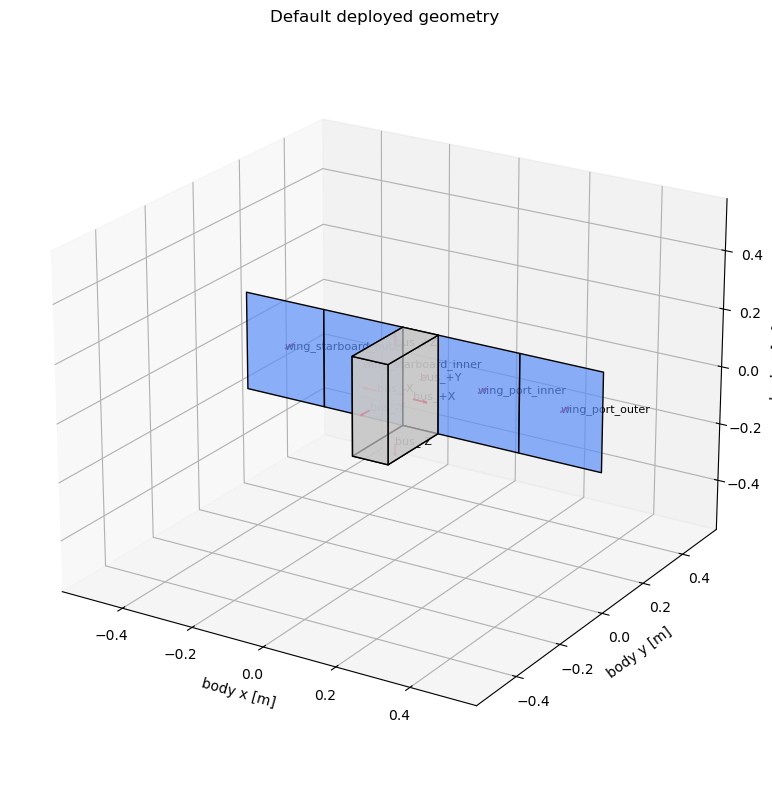

In [14]:
plot_realized_geometry(realized_default, title='Default deployed geometry')
plt.show()


## Step 3: Apply the Mounted Body-Frame Mapping

This step defines the one mounted configuration used by the rest of the notebook. The geometry itself stays the same; only the rigid geometry-frame -> body-frame attachment changes.

The mapping below is chosen so the large 6U bus faces move to `+/-Y`, the deployed 4-panel solar-array normal moves to `+Z`, and geometry `+Z` becomes body `+X`.


mount offset [m]: [0.0, 0.0, 0.0]
geometry +X -> body (0.0, 1.0, 0.0)
geometry +Y -> body (0.0, 0.0, 1.0)
geometry +Z -> body (1.0, 0.0, 0.0)

mounted role table:
name                     normal   +u       +v       center [m]                     tags
---------------------------------------------------------------------------------------
bus_+X                   +Y       +X       -Z       (0.0, 0.05, 0.0)               bus, +X
bus_-X                   -Y       +X       +Z       (0.0, -0.05, 0.0)              bus, -X
bus_+Y                   +Z       +X       +Y       (0.0, 0.0, 0.1132)             bus, +Y
bus_-Y                   -Z       +X       -Y       (0.0, 0.0, -0.1132)            bus, -Y
bus_+Z                   +X       +Y       +Z       (0.1703, 0.0, 0.0)             bus, +Z
bus_-Z                   -X       +Y       -Z       (-0.1703, 0.0, 0.0)            bus, -Z
wing_port_inner          +Z       +X       +Y       (0.0, 0.1632, 0.1132)          deployable, solar_panel, port, i

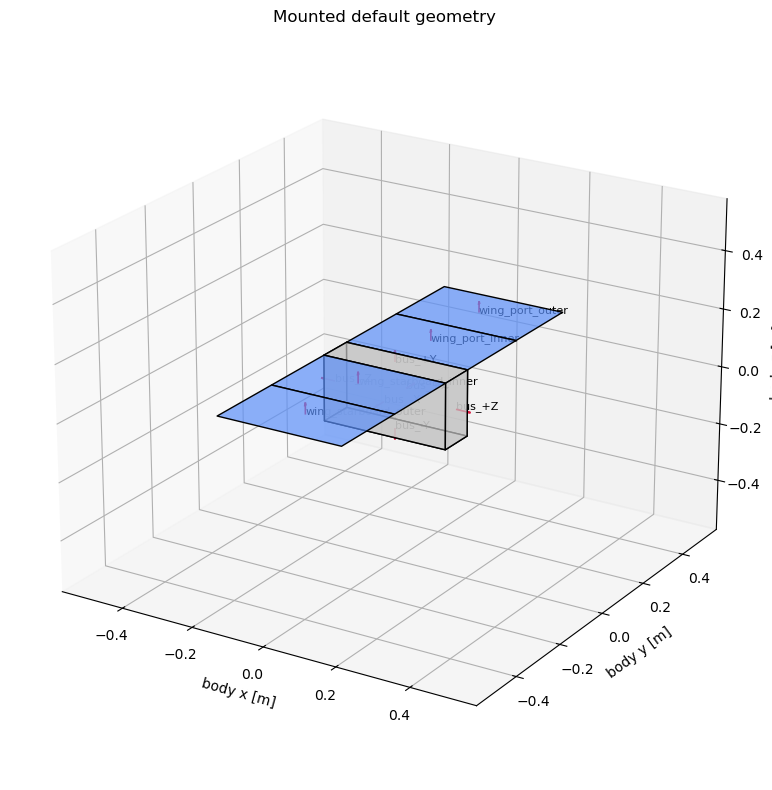

In [15]:
mount_rotation = SO3(np.array([
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
]))
mount_offset = np.array([0.0, 0.0, 0.0])

realized_mounted = cubesat.realize(
    mount_rotation=mount_rotation,
    mount_offset=mount_offset,
)

print('mount offset [m]:', mount_offset.tolist())
for label, axis in [('+X', [1.0, 0.0, 0.0]), ('+Y', [0.0, 1.0, 0.0]), ('+Z', [0.0, 0.0, 1.0])]:
    mapped = np.round(mount_rotation.apply(axis), 4)
    print(f'geometry {label} -> body {tuple(mapped.tolist())}')
print()
print('mounted role table:')
print_mounted_role_table(realized_mounted)
print()
print('body +Y bus face      :', surface_by_normal(realized_mounted, [0.0, 1.0, 0.0], tag='bus').name)
print('body +Z solar panels  :', [surface.name for surface in realized_mounted.by_tag('solar_panel') if np.allclose(surface.normal, [0.0, 0.0, 1.0])])

plot_realized_geometry(
    realized_mounted,
    title='Mounted default geometry',
)
plt.show()


## Step 4: Simple nearest-hit ray check

This is still not the full view-factor propagator. It is a quick sanity check on the mounted geometry: from a source point and direction, what spacecraft surface is hit first?


In [16]:
realized_diagnostic = realized_mounted
source_face = surface_by_normal(realized_diagnostic, [0.0, 1.0, 0.0], tag='bus')


In [17]:
origin = source_face.center + 1e-4 * source_face.normal
direction = source_face.normal

hit = realized_diagnostic.first_intersection(origin, direction, exclude=(source_face.name,))
print('body-frame source role : body +Y bus face')
print('surface name           :', source_face.name)
print('surface normal         :', tuple(np.round(source_face.normal, 4).tolist()))
print('ray origin             :', np.round(origin, 6))
print('ray direction          :', np.round(direction, 6))
print('first hit              :', None if hit is None else (hit[0].name, round(hit[1], 6)))


body-frame source role : body +Y bus face
surface name           : bus_+X
surface normal         : (0.0, 1.0, 0.0)
ray origin             : [0.     0.0501 0.    ]
ray direction          : [0. 1. 0.]
first hit              : None


## Step 5: Patch-by-ray spacecraft self-occlusion

This is the new bridge into the future view-factor workflow. For the mounted body `+Y` bus face, we sample the outward hemisphere in the source local frame, ray-test those directions against the realized spacecraft geometry, and measure what fraction of the source patches are blocked.

The top panel is in direction space: each pixel is one look direction from the source face. The bottom panel is in panel space: each pixel is one face patch, colored by how often that patch is blocked across the sampled directions. The patch plot now labels the local `u`, `v`, and normal directions in body-frame terms.

This is not yet an Earth-disk propagation. It is a geometry-only visibility diagnostic. But it is the same structural test the Earth-disk integrator will need next.


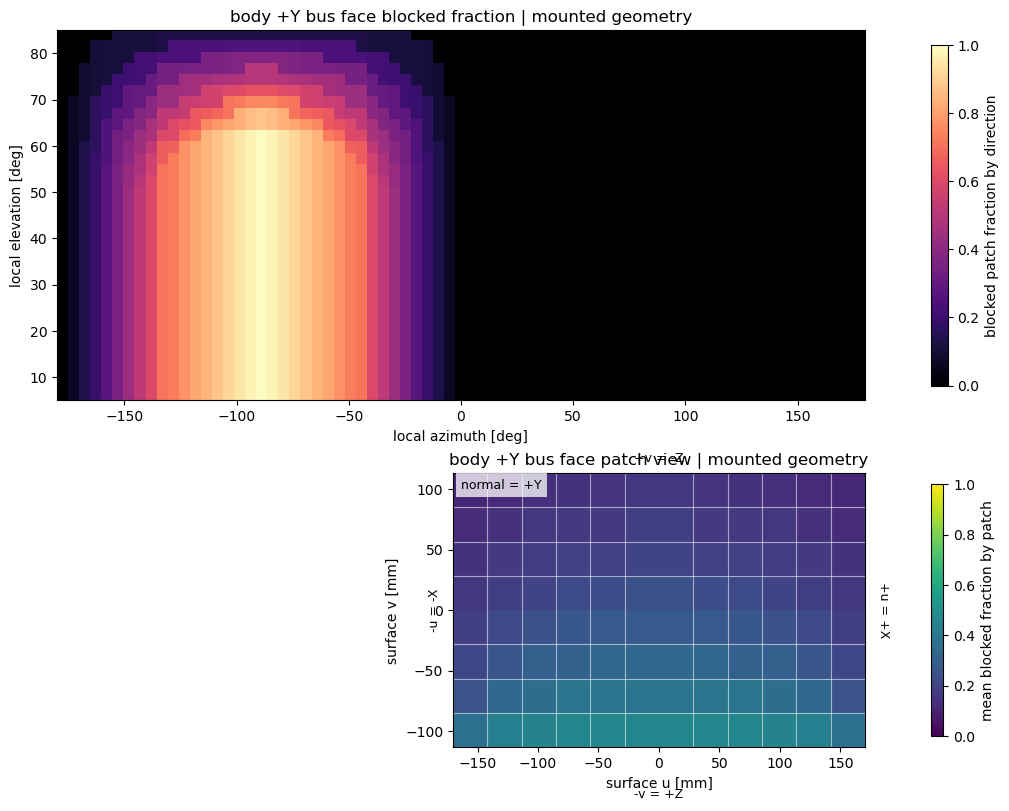

body-frame source role  : body +Y bus face
surface name            : bus_+X
surface normal          : (0.0, 1.0, 0.0)
patch frame             : u -> +X, v -> -Z, normal -> +Y
patch edges             : left -> -X, right -> +X, top -> -Z, bottom -> +Z
mean blocked fraction   : 0.252
max blocked fraction    : 1.0
mean patch blockage     : 0.252


In [18]:
dirs_default, azimuth_deg, elevation_deg = hemisphere_directions(source_face)
visible_default = spacecraft_occlusion_mask(realized_diagnostic, source_face, dirs_default)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1.15, 0.85]},
)

image_dir, blocked_default = plot_occlusion_heatmap(
    axes[0],
    visible_default,
    azimuth_deg,
    elevation_deg,
    title='body +Y bus face blocked fraction | mounted geometry',
)

image_patch, patch_default = plot_patch_occlusion_map(
    axes[1],
    visible_default,
    source_face,
    title='body +Y bus face patch view | mounted geometry',
)

fig.colorbar(image_dir, ax=axes[0], shrink=0.92, label='blocked patch fraction by direction')
fig.colorbar(image_patch, ax=axes[1], shrink=0.92, label='mean blocked fraction by patch')
plt.show()

u_label, v_label, n_label = face_frame_labels(source_face)
print('body-frame source role  : body +Y bus face')
print('surface name            :', source_face.name)
print('surface normal          :', tuple(np.round(source_face.normal, 4).tolist()))
print('patch frame             :', f'u -> {u_label}, v -> {v_label}, normal -> {n_label}')
print('patch edges             :', f'left -> {opposite_axis_label(u_label)}, right -> {u_label}, top -> {v_label}, bottom -> {opposite_axis_label(v_label)}')
print('mean blocked fraction   :', round(float(blocked_default.mean()), 3))
print('max blocked fraction    :', round(float(blocked_default.max()), 3))
print('mean patch blockage     :', round(float(patch_default.mean()), 3))
